In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
import numpy as np
from decimal import Decimal

from scipy.optimize import curve_fit

import astropy.units as u
from astropy.coordinates import Angle, SkyCoord, EarthLocation, AltAz
from astropy.time import Time
from astropy.table import Table

import warnings

In [7]:
# Open the file
filename="/Users/saveriolombardi/Astri_Analyses/hands-on/IN/data/20250130_MA01_Crab_W0.50p090_00000951_R_001909_0201.lv1c.fits"
extension = "EVENTS"
file = Table.read(filename, hdu=extension)
file

VT,TIME_UTC,TIME_S,TIME_NS,EVT_CTR,SIZE,MEANX,MEANY,LENGTH,WIDTH,DELTA,ASYM,CONC,MDIST,M3LONG,LEAKAGE,DIST,MISS,ALPHA,COSDELTAALPHA,NUMISLAND,SIZEMISL,NUMCORE,NUMBOUNDARY,ZD,AZ,XSRCPOS,YSRCPOS,GAMMANESS,EST_EN,DISP,XDISP,YDISP
,,s,ns,,pe,deg,deg,deg,deg,rad,deg,,deg,deg,,deg,deg,deg,,,pe,,,deg,deg,deg,deg,,TeV,deg,deg,deg
bool,bytes19,int32,int32,uint32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,uint16,float32,uint16,uint16,float32,float32,float32,float32,float32,float32,float32,float32,float32
False,2025-01-30T22:57:08,160441028,6170418,0,106.38668,3.4016612,2.0245936,0.24968706,0.1677322,0.28216738,-0.21476084,0.2900892,0.21922643,0.12676808,0.037930578,4.2555065,0.65038973,8.791245,0.98825175,1,106.38668,5,8,14.03322,248.97786,-0.4564472,0.2289499,0.0175,86.467316,3.9271295,7.173489,3.1180556
False,2025-01-30T22:57:08,160441028,12090794,1,5526.2896,0.7322913,-1.581429,0.7075131,0.39609414,-1.4003842,-0.4957259,0.13400513,0.5040409,-0.70634913,0.0,2.1657727,0.86450005,23.52597,0.9168792,1,5526.2896,116,69,14.03322,248.97786,-0.4564472,0.2289499,0.024,19.812016,0.8669185,0.8793107,-2.43579
False,2025-01-30T22:57:08,160441028,5665856,2,178.22063,-0.5164115,2.7094173,0.5105791,0.17218271,1.3091118,-0.5269555,0.18831503,0.53668195,-0.36955217,0.0,2.481192,0.6996397,16.378246,0.95942104,1,178.22063,6,15,14.03322,248.97786,-0.4564472,0.2289499,0.018333333,22.750116,2.9827845,0.25525895,5.590655
False,2025-01-30T22:57:08,160441028,13503804,3,260.7311,-2.951954,-0.0054319464,0.28990287,0.12061988,0.94059,-0.13324328,0.3158295,0.13370596,-0.21417549,0.0,2.5064893,1.8780109,48.52627,-0.6622766,1,260.7311,10,7,14.03322,248.97786,-0.4564472,0.2289499,0.6843214,1.5012442,0.88197476,-2.4321961,0.7071207
False,2025-01-30T22:57:08,160441028,1504743,4,168.5,0.3933857,-2.4684122,0.29758444,0.25562486,-1.1559645,0.42133528,0.18517095,0.42699733,0.13447317,0.0,2.8280697,-0.3093805,-6.2805185,0.9939982,1,168.5,9,9,14.03322,248.97786,-0.4564472,0.2289499,0.0,22.918312,1.3104397,-0.13476868,-1.2691185
False,2025-01-30T22:57:08,160441028,2054139,5,1761.0558,-1.1507081,-3.821312,0.5953881,0.27790692,0.27355462,-0.5161859,0.12760517,0.5195517,-0.37324739,0.049627297,4.109333,-3.7121007,-64.599846,-0.4289374,1,1761.0558,55,22,14.03322,248.97786,-0.4564472,0.2289499,0.0,116.207954,3.1818569,1.9128368,-2.9617155
False,2025-01-30T22:57:08,160441028,2568585,6,130.33473,1.5363063,-0.94642437,0.24386355,0.12356817,-0.018604599,-0.13327703,0.2999051,0.14003931,0.11577127,0.0,2.3135624,-1.1380986,-29.46717,0.8706377,1,130.33473,6,5,14.03322,248.97786,-0.4564472,0.2289499,0.2475,1.4051999,0.95804715,2.4941876,-0.9642474
False,2025-01-30T22:57:08,160441028,9027047,9,110.915146,-1.6531729,-3.2258952,0.34087345,0.14975381,0.45552444,-0.1563063,0.21200809,0.18178545,0.16736513,0.0,3.6562424,-2.5760765,-44.79477,-0.709635,1,110.915146,5,10,14.03322,248.97786,-0.4564472,0.2289499,0.21091667,20.79451,2.9480276,0.99424577,-1.9289596


[]

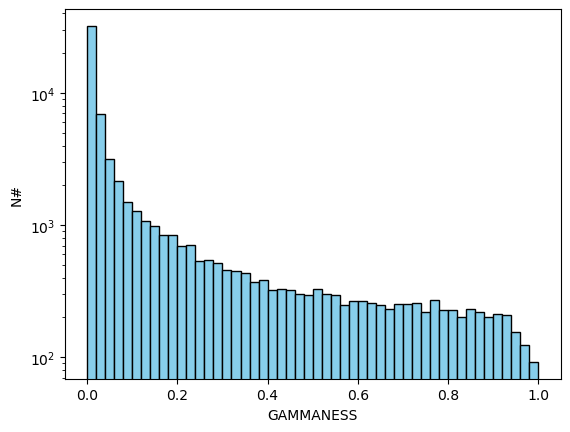

In [8]:
# Make an histogram
parameter="GAMMANESS"
cuts=(file["SIZE"]>200) & (file["LEAKAGE"]<0.1)
plt.hist(file[parameter][cuts], bins=50, color='skyblue', edgecolor='black')
plt.ylabel("N#")
plt.xlabel(parameter)
plt.semilogy()

Text(0, 0.5, 'MEANY')

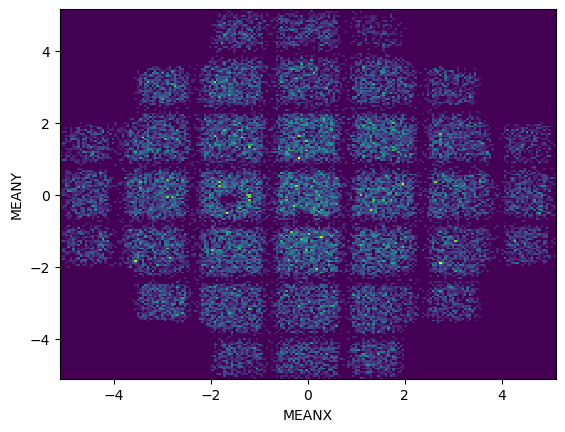

In [9]:
# Make a 2D histogram
parameter1="MEANX"
parameter2="MEANY"
cuts2=(file["SIZE"]>50) & (file["SIZE"]<100)
plt.hist2d(file[parameter1][cuts2], file[parameter2][cuts2], bins=(200,200))
plt.xlabel(parameter1)
plt.ylabel(parameter2)

[]

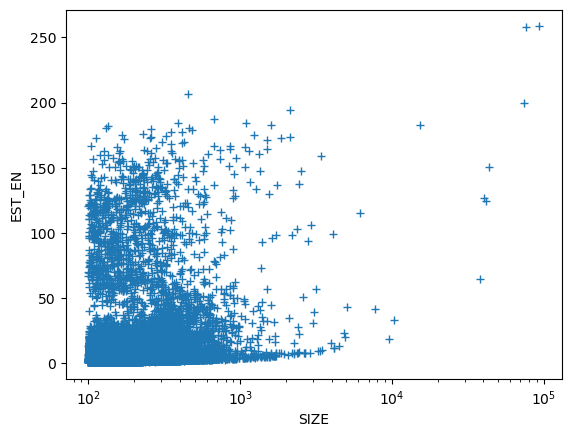

In [10]:
# Make a scatter plot
parameter1="SIZE"
parameter2="EST_EN"
cuts2=(file["SIZE"]>100) & (file["LEAKAGE"]<0.1) & (file["GAMMANESS"]>0.5)
plt.plot(file[parameter1][cuts2], file[parameter2][cuts2],"+") #use `+,o,*` for points or `-` for lines
plt.xlabel(parameter1)
plt.ylabel(parameter2)
plt.semilogx()